# FuzzSys: Fuzzy Data Interpretation

This notebook shows multiple examples regarding fuzzy concept definition using the command-line definer. All input data sets are downloaded and processed from The Cancer Genome Atlas Project (TCGA). Nine cancer types were selected, which include at least 30 patients with both collected miRNA- and RNA-seq data from primary tumour and solid normal tissue. Among the protein-coding genes, 13,274 genes with sufficient expression in any of the tissue and cancer types remained after filtering. To compare gene expression in primary tumour and solid normal tissue, pairs of tumour and normal samples collected from the same patient were built, resulting in 487 such sample pairs in the data set.

In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from helper_example import plotVolcano, plotConcept

%load_ext autoreload
%autoreload 2

## Matrix-wise fuzzy concept derivation

DESeq2 was used for differential expression analysis, which compares tumour and normal expression in each cancer type, i.e. nine pair-wise comparisons. The corrected \textit{p}-values were negative log10-transformed as significance, and all corrected \textit{p}-values lower than $10^{-10}$ were rounded up to $10^{-10}$.

#features:	13275
#comparisons:	9


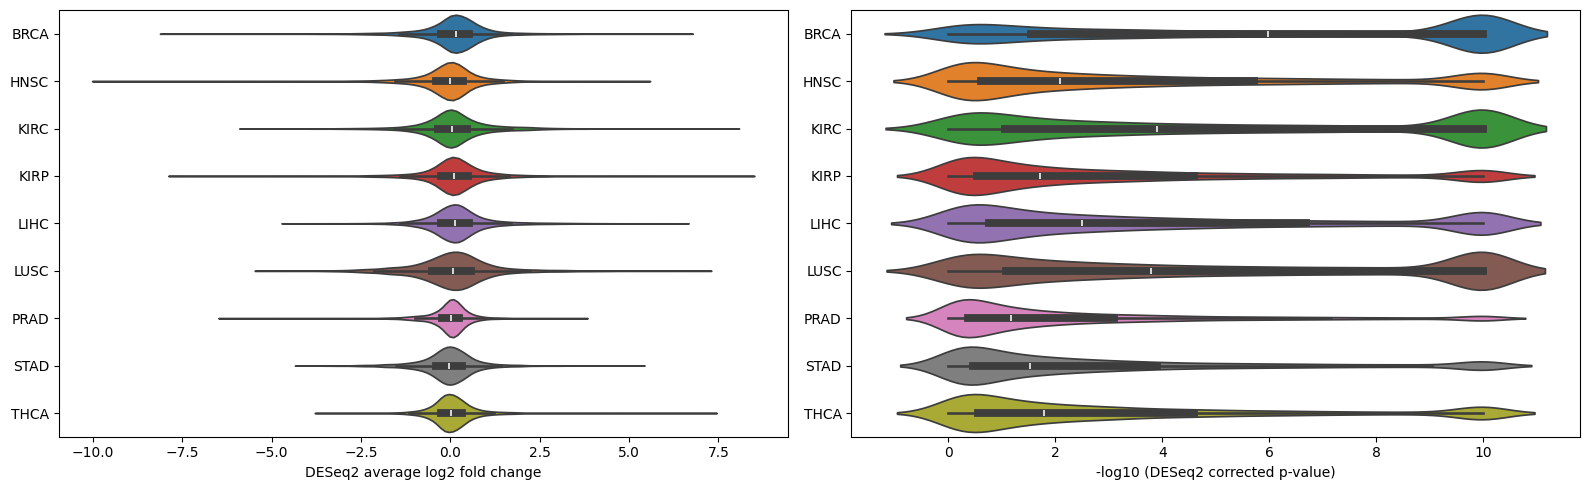

In [ ]:
padj = pd.read_csv ("DESeq2_padj.tsv", index_col = 0, sep = "\t")
log2FC = pd.read_csv ("DESeq2_log2FC.tsv", index_col = 0, sep = "\t")
print (f"#features:\t{log2FC.shape[0]}"); print (f"#comparisons:\t{log2FC.shape[1]}")

volcano = log2FC.reset_index (names = "feature").melt (id_vars = "feature", var_name = "cluster", value_name = "log2FC")
volcano = volcano.merge (padj.reset_index (names = "feature").melt (id_vars = "feature", var_name = "cluster", value_name = "padj"),
                         on = ["feature", "cluster"], how = "inner")

fig, axs = plt.subplots (1, 2, sharex = False, sharey = False, figsize = (16, 5))
sns.violinplot (volcano, x = "log2FC", y = "cluster", order = sorted (set (volcano["cluster"])),
                hue = "cluster", hue_order = sorted (set (volcano["cluster"])), ax = axs[0])
axs[0].set_xlabel ("DESeq2 average log2 fold change", size = 10); axs[0].set_ylabel ("")
sns.violinplot (volcano, x = "padj", y = "cluster", order = sorted (set (volcano["cluster"])),
                hue = "cluster", hue_order = sorted (set (volcano["cluster"])), ax = axs[1])
axs[1].set_xlabel ("-log10 (DESeq2 corrected p-value)", size = 10); axs[1].set_ylabel ("")
fig.tight_layout (); plt.show ()

Due to the large fraction of high significance, the conventional threshold 0.05 is far from enough to interprete and classify the data. Therefore, five categories / fuzzy sets are defined to classify significance from not significant ($\circ$) to highly significant ($****$). These fuzzy sets are separated by constant cutoffs, namely $-\log_{10}0.05$, $10^{-3}$, $10^{-5}$ and $10^{-7}$, and the degree of belongingness / fuzzy values are calculated by trapezoidal membership funtions, respectively.

A config file is required for the semi-automatic fuzzy concept derivation.

``` py title="config_padj.json"
{
    "label_zero": True, # Infinity and missing values are detected automatically, labelling of zeros must be noted in the config.
    "key_default_concept": "DEFAULT", # name of the default / matrix-wise fuzzy concept
    "define_concept_per": "matrix", # options: feature / sample / matrix
    "define_concept_by": "constraint", # options: default / constraint
    "fuzzy_variables": ["o", "*", "**", "***", "****"], # linguistic term for each fuzzy set
    "colors": ["#3CB371", "#FF9896", "#FFBB78", "#FF7F0E", "#D62728"], # colors for visualization
    "parameters_constraint": {
        "constraint_type": "fixed", # options: fixed / proportion / z-score
        "constraints": [
            [-1, -1, 0.95, 1.65], # four x-coordinates of the trapezoid
            [0.95, 1.65, 2.5, 3.5],
            [2.5, 3.5, 4.5, 5.5],
            [4.5, 5.5, 6.5, 7.5],
            [6.5, 7.5, 11, 11]
        ]
    }
}
```

In contrast to significance, the DESeq2 log2 fold change values are categorized with five fuzzy sets, representing strong down-regulation ($--$) to no regulation ($\circ$) to strong up-regulation ($++$). The membership functions are derived from a Gaussian function fitted to the whole value distribution in the matrix. Here, we do not introduce any constant noise cutoffs. Instead, we use the default fuzzification method for fuzzy concept derivation. It fits a Gaussian function to the estimated density according to a certain band width factor. Then a fuzzy concept is derived, with membership functions symmetric at the fitted $\mu$. The width of the Gaussian function in the middle as well as that of the trapezoidal functions on both sides can be adjusted by a global width factor. And the proportion of slope region is determined by an additional factor.

``` py title="config_log2FC.json"
{
    "label_zero": False,
    "key_default_concept": "DEFAULT",
    "define_concept_per": "matrix",
    "define_concept_by": "default", # default fuzzification method
    "fuzzy_variables": ["--", "-", "o", "+", "++"],
    "colors": ["blue", "steelblue", "green", "firebrick", "red"],
    "parameters_default": {
        "number_fuzzy_sets_per_side": 2,
        "band_width_factor": 0.75,
        "width_scale_factor": 0.5,
        "slope_percentage": 0.5,
        "use_scipy_optimization": False # whether to use SciPy optimize module for sigma derivation
    }
}
```

Then we save the config in `config_padj.json` and `config_log2FC.json`. Then we call `main_concepts.py` to generate matrix-wise fuzzy concepts as well as a default (matrix-wise) concept with the command-line definer.

``` bash title="script directory"
python main_concepts.py --mtx DESeq2_padj.tsv \
	--config config_padj.json \
	--output ./concepts_padj/

python main_concepts.py --mtx DESeq2_log2FC.tsv \
	--config config_log2FC.json \
	--output ./concepts_log2FC/
```

Two output files will be generated. In this matrix-wise fuzzification of significance with constants as constraints, both outputs are almost identical. As for DESeq2 log2 fold change, z-scores are derived as constraints.

- `concepts_constraints.json`: Constraints of the derived fuzzy concept, which can be used to regenerate fuzzy concepts based on another matrix.

- `concepts_detailed.json`: Concrete fuzzy concepts with calculated values according to the input matrix.

Example for significance:

``` py title="significance"
{
    "number_fuzzy_sets": 5,
    "label_values": [0],
    "MIN-NOISE": "-Infinity",
    "MAX-NOISE": "Infinity",
    "o": [[-1, -1, 0.95, 1.65], "trapezoidal", "#3CB371", 0.37472],
    "*": [[0.95, 1.65, 2.5, 3.5], "trapezoidal", "#FF9896", 0.19029],
    "**": [[2.5, 3.5, 4.5, 5.5], "trapezoidal", "#FFBB78", 0.12193],
    "***": [[4.5, 5.5, 6.5, 7.5], "trapezoidal", "#FF7F0E", 0.07434],
    "****": [[6.5, 7.5, 11, 11], "trapezoidal", "#D62728", 0.23871]
}
```

Example for DESeq2 log2 fold change:

``` py title="DESeq2 log2 fold change"
{
    "number_fuzzy_sets": 5,
    "label_values": [],
    "MIN-NOISE": "-Infinity",
    "MAX-NOISE": "Infinity",
    "--": [
        [-11.0, -11.0, -1.512, -1.066],
        "trapezoidal",
        "#1F77B4",
        0.06681
    ],
    "-": [
        [-1.512, -1.066, -0.62, -0.174],
        "trapezoidal",
        "#FF7F0E",
        0.22996
    ],
    "o": [
        [0.049, 0.446],
        "Gaussian",
        "#2CA02C",
        0.40629
    ],
    "+": [
        [0.272, 0.718, 1.164, 1.61],
        "trapezoidal",
        "#D62728",
        0.23013
    ],
    "++": [
        [1.164, 1.61, 10.0, 10.0],
        "trapezoidal",
        "#9467BD",
        0.06681
    ]
}
```

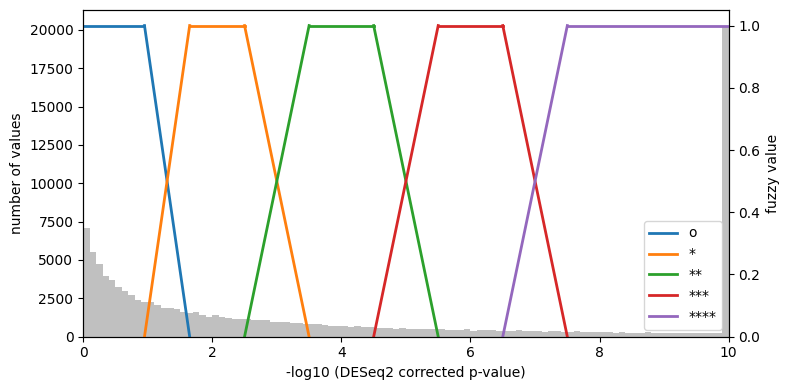

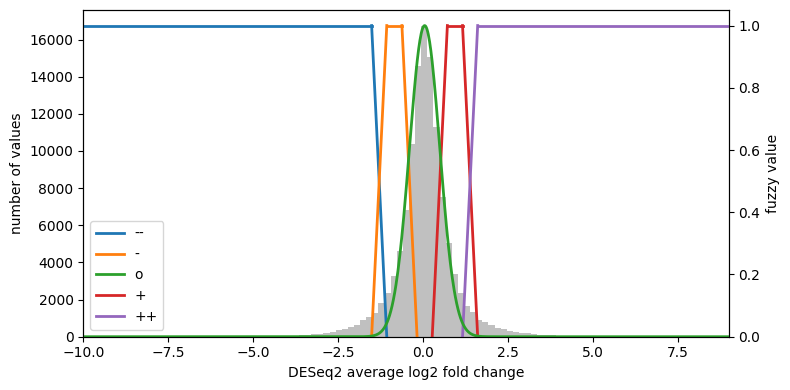

In [ ]:
with open ("./concepts_padj/concepts_detailed.json") as f:
    padj_concept = json.load (f)["DEFAULT"]
plotConcept (padj, padj_concept, "-log10 (DESeq2 corrected p-value)")

with open ("./concepts_log2FC/concepts_detailed.json") as f:
    log2FC_concept = json.load (f)["DEFAULT"]
plotConcept (log2FC, log2FC_concept, "DESeq2 average log2 fold change")

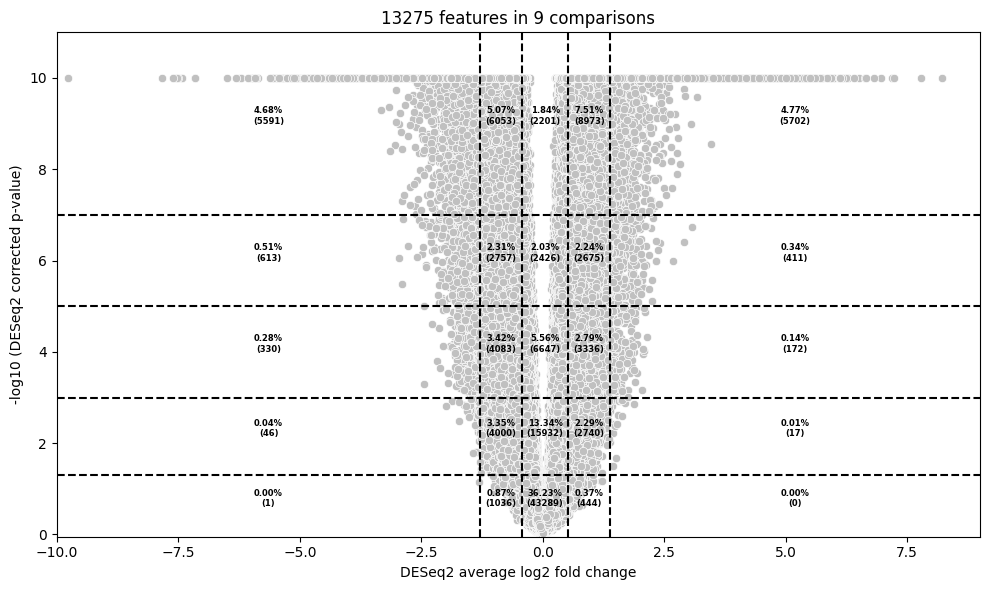

In [4]:
plotVolcano (log2FC, padj, log2FC_concept, padj_concept)

## Sample-wise fuzzification from fitting

Fuzzy concepts are defined for each sample pair, with the following two assumptions:

- For each sample pair, most of the features are rather unregulated.

- The log2 fold change for each sample pair follows a normal distribution, since there is a sufficient number of features available (Law of Large Numbers).

Therefore, a Gaussian function is fitted for each sample pair. And we would require five fuzzy sets ($--$, $-$, $\circ$, $+$, $++$), whose membership functions are derived from the fitted $\mu$ and $\sigma$.

#features:	13275
#sample pairs:	487


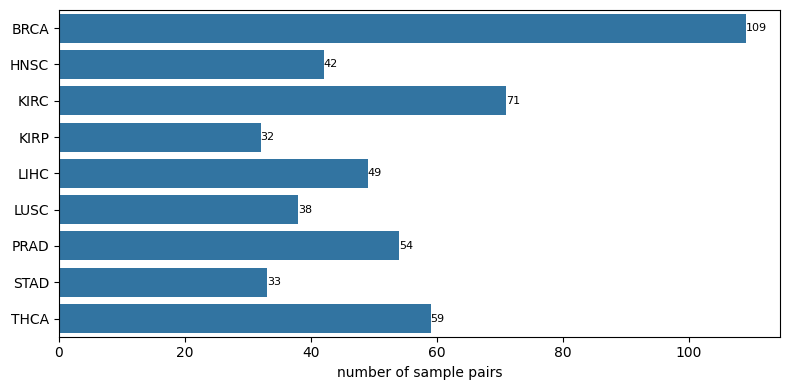

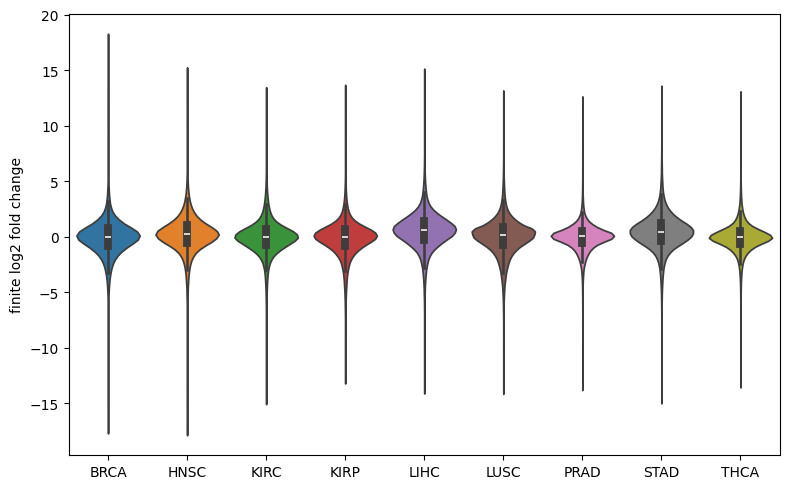

In [ ]:
data = pd.read_csv ("paired_log2FC.tsv", index_col = 0, sep = "\t")
metadata = pd.read_csv ("metadata.tsv", index_col = None, sep = "\t").rename (columns = {"context": "cluster"})
allClusters = sorted (set (metadata["cluster"]))
print (f"#features:\t{data.shape[0]}"); print (f"#sample pairs:\t{data.shape[1]}")

fig, ax = plt.subplots (figsize = (8, 4))
sns.barplot (metadata.value_counts ("cluster").sort_index ().reset_index (), x = "count", y = "cluster", ax = ax)
ax.bar_label (ax.containers[0], fontsize = 8)
ax.set_xlabel ("number of sample pairs", size = 10); ax.set_ylabel ("")
fig.tight_layout (); plt.show ()

pltData = data.mask (~np.isfinite (data)).melt ()
pltData["cluster"] = metadata.set_index ("sample").loc[pltData["variable"], "cluster"].values
fig, ax = plt.subplots (figsize = (8, 5))
sns.violinplot (pltData, x = "cluster", y = "value", order = allClusters, hue = "cluster", hue_order = allClusters, ax = ax)
ax.set_xlabel (""); ax.set_ylabel ("finite log2 fold change", size = 10)
fig.tight_layout (); plt.show ()

We still choose the default fuzzification method for fuzzy concept derivation. A config file for this method would be:

``` py title="config.json"
{
    "label_zero": False,
    "left_noise_cutoff_constant": "-Infinity", # constant cutoff for small values as noise (MIN-NOISE)
    "right_noise_cutoff_constant": "+Infinity", # constant cutoff for large values as noise (MAX-NOISE)
    "left_noise_cutoff_percent": 0.05, # percent cutoff for small values as noise, feature- or sample-specific
    "right_noise_cutoff_percent": 0.95, # percent cutoff for large values as noies, feature- or sample-specific
    "key_default_concept": "DEFAULT",
    "define_concept_per": "sample",
    "define_concept_by": "default",
    "fuzzy_variables": ["DOWN", "down", "MEDIUM", "up", "UP"],
    "colors": ["blue", "steelblue", "green", "firebrick", "red"],
    "parameters_default": {
        "number_fuzzy_sets_per_side": 2,
        "band_width_factor": 0.75,
        "width_scale_factor": 0.5,
        "slope_percentage": 0.5,
        "use_scipy_optimization": True
    }
}
```

Then we save the config in `config.json` and generate sample-wise fuzzy concepts and a default (matrix-wise) concept with the command-line definer.

``` bash title="script directory"
python main_concepts.py --mtx paired_log2FC.tsv \
	--config config.json \
	--output ./concepts/
```

Two output files will be generated.

- `concepts_constraints.json`: Constraints of the derived fuzzy concept, which can be used to regenerate fuzzy concepts based on another matrix.

- `concepts_detailed.json`: Concrete fuzzy concepts with calculated values according to the input matrix.

Examples for sample `TCGA-BD-A3EP_0`:

``` py
{
    "number_fuzzy_sets": 5,
    "label_values": [
        "-Infinity",
        "Infinity",
        "NA"
    ],
    "MIN-NOISE": -1.174,
    "MAX-NOISE": 2.608,
    "--": [
        [-3.0, -3.0, -1.934, -1.178],
        "trapezoidal",
        "#1F77B4",
        0
    ],
    "-": [
        [-1.934, -1.178, -0.422, 0.334],
        "trapezoidal",
        "#FF7F0E",
        0.13686
    ],
    "o": [
        [0.712, 0.756],
        "Gaussian",
        "#2CA02C",
        0.71368
    ],
    "+": [
        [1.09, 1.846, 2.602, 3.358],
        "trapezoidal",
        "#D62728",
        0.13708
    ],
    "++": [
        [2.602, 3.358, 5.0, 5.0],
        "trapezoidal",
        "#9467BD",
        0
    ]
}
```

For each sample pair, the log2 fold change values are fuzzified using the corresponding fuzzy concept. If there is no fuzzy concept available for some sample pairs, the default fuzzy concept will be applied. A config file `config_fuzzy.json` is also required for this step. Noise cutoffs will be ignored if the fuzzy concepts are not to be regenerated.

``` py title="config_fuzzy.json"
{
    "key_default_concept": "DEFAULT",
    "fuzzify_per": "sample",
    "ignore_MIN-NOISE": True, # whether to ignore MIN-NOISE in the fuzzy concept
    "ignore_MAX-NOISE": True, # whether to ignore MAX-NOISE in the fuzzy concept
    "force_sum_one": True, # whether to force sum of fuzzy values to each raw value to 1
    "rename_labels": { # assign fuzzy variable for the special values
        "NAN": "NA",
        "-Infinity": "-INF",
        "Infinity": "+INF"
    },
    "generate_evaluation": True, # whether to generate evaluation tables and plots
    "generate_report_plots": False # whether to generate individual fuzzy reports for each feature / sample
}
```

Then we call `main_fuzzify.py` for fuzzification:

``` bash
python main_fuzzify.py --mtx paired_log2FC.tsv \
	--concept ./concepts/concepts_detailed.json \
	--config config.json \
	--output ./results/
```

In [ ]:
exampleFV = pd.read_csv ("./results/fuzzy_values/fuzzyValues_TCGA-BD-A3EP_0.tsv",
                         index_col = 0, sep = "\t")
print (exampleFV.head ())

        -INF  +INF   NA     --      -      o      +   ++
A2M      0.0   0.0  0.0  0.195  0.779  0.025  0.000  0.0
A4GALT   0.0   0.0  0.0  0.000  0.000  0.263  0.737  0.0
AAAS     0.0   0.0  0.0  0.000  0.000  1.000  0.000  0.0
AACS     0.0   0.0  0.0  0.000  0.000  1.000  0.000  0.0
AADAT    0.0   0.0  0.0  1.000  0.000  0.000  0.000  0.0
